<a href="https://colab.research.google.com/github/SitiMutmainah15/PEMBELAJARAN-MESIN_GENAP_2026/blob/main/JS05/TugasLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

soal no 1

In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv('voice.csv')

# Tampilkan 5 data pertama
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Cek informasi dataset
data.info()

# Statistik deskriptif
data.describe()

# Cek jumlah data setiap kelas
data['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,count
label,
male,1584
female,1584


In [3]:
X = data.iloc[:, :-1]   # semua kolom kecuali label
y = data.iloc[:, -1]    # kolom label

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("Label:")
print(y.value_counts())

Jumlah fitur: 20
Jumlah data: 3168
Label:
label
male      1584
female    1584
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split 70% training dan 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Standardisasi
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (2217, 20)
Data testing : (951, 20)


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Model kNN dengan k = 3
knn = KNeighborsClassifier(n_neighbors=3)

# Training
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Akurasi:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9768664563617245

Confusion Matrix:
[[440  12]
 [ 10 489]]

Laporan Klasifikasi:
              precision    recall  f1-score   support

      female       0.98      0.97      0.98       452
        male       0.98      0.98      0.98       499

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



Model kNN dengan seluruh fitur dan k = 3 menghasilkan akurasi 97,69%, sehingga mampu mengklasifikasikan suara male dan female dengan baik.

soal no 2

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Pisahkan fitur dan label dari data asli
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

hasil_fitur = []

# Percobaan jumlah fitur 1 sampai seluruh fitur
for n in range(1, X.shape[1] + 1):

    # Seleksi fitur berdasarkan data training
    selector = SelectKBest(score_func=f_classif, k=n)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    # Standardisasi
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_test_scaled = scaler.transform(X_test_selected)

    # kNN menggunakan k=3
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_scaled, y_train)

    # Prediksi
    y_pred = knn.predict(X_test_scaled)

    # Hitung akurasi
    akurasi = accuracy_score(y_test, y_pred)

    # Nama fitur yang terpilih
    fitur_terpilih = X.columns[selector.get_support()].tolist()

    hasil_fitur.append({
        'Jumlah Fitur': n,
        'Akurasi': akurasi,
        'Fitur Terpilih': ', '.join(fitur_terpilih)
    })

# Jadikan DataFrame
hasil_df = pd.DataFrame(hasil_fitur)

hasil_df

,Jumlah Fitur,Akurasi,Fitur Terpilih
0,1,0.940063,meanfun
1,2,0.966351,"IQR, meanfun"
2,3,0.966351,"Q25, IQR, meanfun"
3,4,0.969506,"Q25, IQR, sp.ent, meanfun"
4,5,0.977918,"sd, Q25, IQR, sp.ent, meanfun"
5,6,0.977918,"sd, Q25, IQR, sp.ent, sfm, meanfun"
6,7,0.981073,"sd, Q25, IQR, sp.ent, sfm, centroid, meanfun"
7,8,0.981073,"meanfreq, sd, Q25, IQR, sp.ent, sfm, centroid,..."
8,9,0.980021,"meanfreq, sd, median, Q25, IQR, sp.ent, sfm, c..."
9,10,0.980021,"meanfreq, sd, median, Q25, IQR, sp.ent, sfm, c..."


In [8]:
hasil_terbaik = hasil_df.loc[hasil_df['Akurasi'].idxmax()]

print("Jumlah fitur terbaik :", hasil_terbaik['Jumlah Fitur'])
print("Akurasi terbaik      :", hasil_terbaik['Akurasi'])
print("Fitur yang digunakan :")
print(hasil_terbaik['Fitur Terpilih'])

Jumlah fitur terbaik : 7
Akurasi terbaik      : 0.9810725552050473
Fitur yang digunakan :
sd, Q25, IQR, sp.ent, sfm, centroid, meanfun


Hasil seleksi fitur menunjukkan 7 fitur terbaik, yaitu sd, Q25, IQR, sp.ent, sfm, centroid, dan meanfun, dengan akurasi 98,11%.

soal no 3

In [9]:
# 7 fitur terbaik berdasarkan percobaan nomor 2
fitur_terbaik = ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun']

X_best = data[fitur_terbaik]
y = data['label']

# Split data
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_best, y,
    test_size=0.3,
    random_state=42
)

# Standardisasi
scaler = StandardScaler()

X_train_best = scaler.fit_transform(X_train_best)
X_test_best = scaler.transform(X_test_best)

In [10]:
train_acc = []
test_acc = []

nilai_k = range(1, 21)

for k in nilai_k:
    model = KNeighborsClassifier(n_neighbors=k)

    # Training
    model.fit(X_train_best, y_train_best)

    # Akurasi training
    train_acc.append(model.score(X_train_best, y_train_best))

    # Akurasi testing
    test_acc.append(model.score(X_test_best, y_test_best))

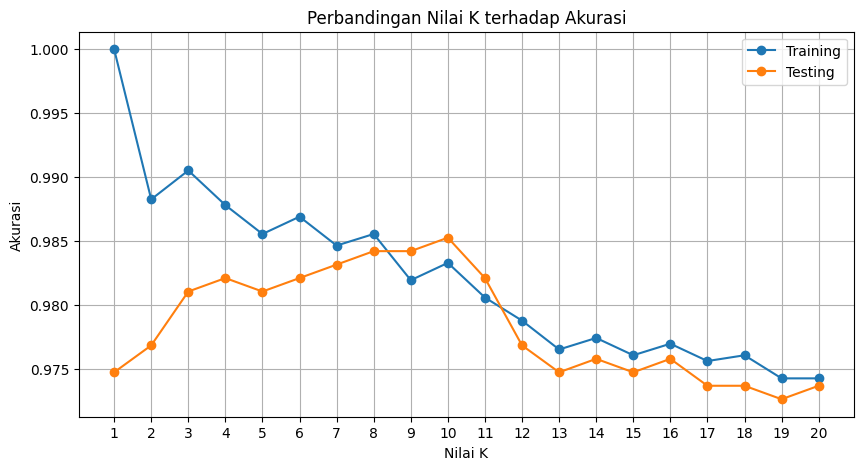

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(nilai_k, train_acc, marker='o', label='Training')
plt.plot(nilai_k, test_acc, marker='o', label='Testing')

plt.title('Perbandingan Nilai K terhadap Akurasi')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.show()

In [12]:
best_index = test_acc.index(max(test_acc))
best_k = list(nilai_k)[best_index]
best_acc = test_acc[best_index]

print("Nilai k terbaik :", best_k)
print("Akurasi testing terbaik :", best_acc)
print("Akurasi training pada k terbaik :", train_acc[best_index])

Nilai k terbaik : 10
Akurasi testing terbaik : 0.9852786540483701
Akurasi training pada k terbaik : 0.9833107803337844


Berdasarkan pengujian k = 1–20, nilai terbaik adalah k = 10 dengan akurasi testing 98,53%. Nilai ini dipilih karena menghasilkan akurasi testing tertinggi pada grafik.